In [1]:

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import statsmodels.api as sm

from IPython.display import Markdown, display
from scipy.stats import norm
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from itertools import combinations

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:.4f}".format

# Resolve data and output locations in a way that works both locally and in /mnt/data.
if Path("low2036upd.csv").exists():
    BASE_DIR = Path.cwd()
elif Path("/mnt/data/low2036upd.csv").exists():
    BASE_DIR = Path("/mnt/data")
else:
    raise FileNotFoundError("Could not find low2036upd.csv in the current folder or in /mnt/data.")

DATA_PATH = BASE_DIR / "low2036upd.csv"
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
covariates = [c for c in df.columns if c not in ["Y", "A"]]

print(f"Treatment variable: A")
print(f"Outcome variable:   Y")
print(f"Number of candidate covariates: {len(covariates)}")

display(df.head())


Treatment variable: A
Outcome variable:   Y
Number of candidate covariates: 22


,Y,A,LIMIT_BAL,SEX,EDUCATION,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,1,0,30000,0,2,39,0,0,0,0,...,30221,29376,29564,28762,1500,1518,1439,1017,1032,1367
1,1,1,110000,0,2,36,1,2,0,0,...,14516,19396,9298,14116,0,5000,5000,0,5000,0
2,1,0,140000,0,2,30,-2,-2,-2,-2,...,107,107,107,107,232,107,107,107,107,107
3,0,0,60000,0,2,31,0,0,0,3,...,57752,56243,55213,58700,3000,10000,0,0,4400,2200
4,0,0,80000,0,2,26,0,0,-1,0,...,35476,24657,12139,9038,1000,35476,1000,243,9038,250


Crude risk difference (treated - untreated): 0.1159


,default_rate,n
A,,
A = 0 (No PPP),0.2274,299
A = 1 (PPP),0.3433,201


,variable,smd
3,AGE,0.8674
2,EDUCATION,0.4106
0,LIMIT_BAL,0.3052
10,BILL_AMT1,0.1478
20,PAY_AMT5,0.1423
21,PAY_AMT6,-0.1233
19,PAY_AMT4,0.1211
13,BILL_AMT4,0.1166
14,BILL_AMT5,0.1153
15,BILL_AMT6,0.1108


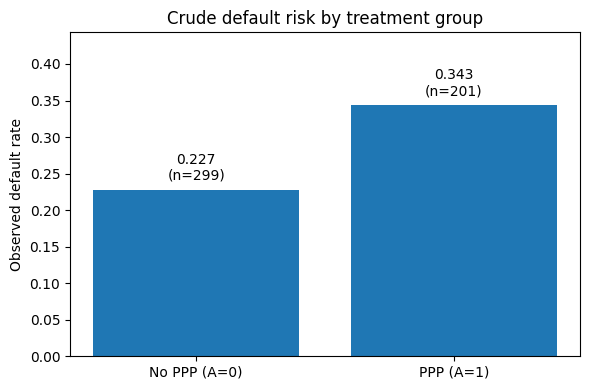

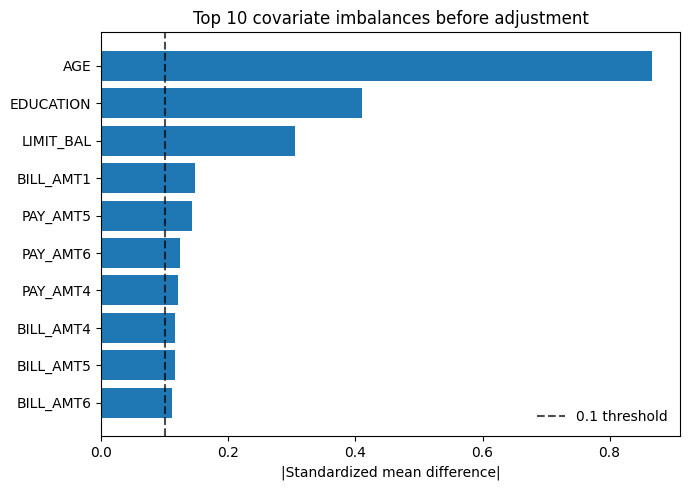

In [2]:

def standardized_mean_differences(data, cols=None, covariates=None, treatment_col="A", weights=None):

    if cols is None:
        cols = covariates
    if cols is None:
        cols = [c for c in data.columns if c != treatment_col]

    a = data[treatment_col].to_numpy()
    w = np.ones(len(data)) if weights is None else np.asarray(weights, dtype=float)

    rows = []
    for col in cols:
        x = data[col].to_numpy(dtype=float)
        mask1 = a == 1
        mask0 = a == 0

        m1 = np.average(x[mask1], weights=w[mask1])
        m0 = np.average(x[mask0], weights=w[mask0])

        v1 = np.average((x[mask1] - m1) ** 2, weights=w[mask1])
        v0 = np.average((x[mask0] - m0) ** 2, weights=w[mask0])

        pooled_sd = np.sqrt((v1 + v0) / 2) if (v1 + v0) > 0 else 0.0
        smd = 0.0 if pooled_sd == 0 else (m1 - m0) / pooled_sd

        rows.append({"variable": col, "smd": float(smd)})

    return pd.DataFrame(rows)

crude_rates = (
    df.groupby("A")["Y"]
      .agg(default_rate="mean", n="count")
      .rename(index={0: "A = 0 (No PPP)", 1: "A = 1 (PPP)"})
)
crude_rd = float(df.loc[df["A"] == 1, "Y"].mean() - df.loc[df["A"] == 0, "Y"].mean())

smd_before = standardized_mean_differences(df, cols=covariates)
smd_before = smd_before.sort_values("smd", key=np.abs, ascending=False)

print(f"Crude risk difference (treated - untreated): {crude_rd:.4f}")
display(crude_rates)
display(smd_before.head(10))

# Plot 1: crude default rates
fig, ax = plt.subplots(figsize=(6, 4))
means = df.groupby("A")["Y"].mean()
counts = df["A"].value_counts().sort_index()
bars = ax.bar(["No PPP (A=0)", "PPP (A=1)"], means.values)

ax.set_ylabel("Observed default rate")
ax.set_title("Crude default risk by treatment group")
ax.set_ylim(0, means.max() + 0.10)

for bar, m, n in zip(bars, means.values, counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{m:.3f}\n(n={n})",
        ha="center", va="bottom", fontsize=10
    )

fig.tight_layout()
fig.savefig(FIG_DIR / "crude_default_rates.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 2: largest absolute imbalances before adjustment
top_smd = smd_before.head(10).sort_values("smd", key=np.abs)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_smd["variable"], top_smd["smd"].abs())
ax.axvline(0.1, linestyle="--", color="black", alpha=0.7, label="0.1 threshold")
ax.set_xlabel("|Standardized mean difference|")
ax.set_title("Top 10 covariate imbalances before adjustment")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "top_smd_before.png", dpi=300, bbox_inches="tight")
plt.show()


In [3]:

def fit_logistic_model(y, X):

    X_with_const = sm.add_constant(X, has_constant="add")
    model = sm.GLM(
        y.astype(float),
        X_with_const.astype(float),
        family=sm.families.Binomial(),
    )
    return model.fit(maxiter=200, disp=0)

def ace_or(data, adjustment_vars):

    X_train = data[["A"] + list(adjustment_vars)].copy()
    model_res = fit_logistic_model(data["Y"], X_train)

    X_treated = X_train.copy()
    X_treated["A"] = 1.0

    X_control = X_train.copy()
    X_control["A"] = 0.0

    mu1 = model_res.predict(sm.add_constant(X_treated, has_constant="add"))
    mu0 = model_res.predict(sm.add_constant(X_control, has_constant="add"))

    ace_estimate = float(np.mean(mu1 - mu0))
    return ace_estimate, model_res

def ace_ipw(data, adjustment_vars, stabilized=True):

    X_train = data[list(adjustment_vars)].copy() if len(adjustment_vars) > 0 else pd.DataFrame(index=data.index)
    model_res = fit_logistic_model(data["A"], X_train)

    ps = np.asarray(model_res.predict(sm.add_constant(X_train, has_constant="add")))
    ps = np.clip(ps, 1e-3, 1 - 1e-3)

    a = data["A"].to_numpy()
    y = data["Y"].to_numpy()
    p_treat = a.mean()

    if stabilized:
        weights = np.where(a == 1, p_treat / ps, (1 - p_treat) / (1 - ps))
    else:
        weights = np.where(a == 1, 1 / ps, 1 / (1 - ps))

    mu1 = np.average(y[a == 1], weights=weights[a == 1])
    mu0 = np.average(y[a == 0], weights=weights[a == 0])

    ace_estimate = float(mu1 - mu0)
    return ace_estimate, model_res, ps, weights

estimate_ace_or = ace_or
estimate_ace_ipw = ace_ipw

def bootstrap_ace(data, adjustment_vars, estimator="or", n_boot=300, seed=42):

    rng = np.random.default_rng(seed)
    boot_estimates = []

    for _ in range(n_boot):
        idx = rng.integers(0, len(data), len(data))
        sample = data.iloc[idx].reset_index(drop=True)

        try:
            if estimator == "or":
                est = ace_or(sample, adjustment_vars)[0]
            elif estimator == "ipw":
                est = ace_ipw(sample, adjustment_vars)[0]
            else:
                raise ValueError("estimator must be 'or' or 'ipw'")
            boot_estimates.append(est)
        except Exception:
            continue

    if len(boot_estimates) == 0:
        raise RuntimeError("All bootstrap replications failed.")

    point_estimate = ace_or(data, adjustment_vars)[0] if estimator == "or" else ace_ipw(data, adjustment_vars)[0]

    return {
        "estimate": float(point_estimate),
        "ci_low": float(np.quantile(boot_estimates, 0.025)),
        "ci_high": float(np.quantile(boot_estimates, 0.975)),
        "n_boot": int(len(boot_estimates)),
    }


In [4]:

def estimate_latent_corr_spearman(data):

    ranked = data.rank(method="average")
    spearman = ranked.corr(method="pearson")
    latent = 2 * np.sin((np.pi / 6.0) * spearman.to_numpy(dtype=float))
    latent = np.clip(latent, -0.999999, 0.999999)
    np.fill_diagonal(latent, 1.0)
    return pd.DataFrame(latent, index=data.columns, columns=data.columns)

rpc_corr = estimate_latent_corr_spearman(df)

def partial_corr_from_corr(corr_df, x, y, conditioning_set=()):

    cols = [x, y] + list(conditioning_set)
    C = corr_df.loc[cols, cols].to_numpy(dtype=float)

    if len(conditioning_set) == 0:
        r = float(C[0, 1])
    else:
        try:
            P = np.linalg.inv(C)
        except np.linalg.LinAlgError:
            P = np.linalg.pinv(C)

        r = -P[0, 1] / np.sqrt(P[0, 0] * P[1, 1])

    return float(np.clip(r, -0.999999, 0.999999))

def partial_corr_pvalue(corr_df, n, x, y, conditioning_set=()):

    r = partial_corr_from_corr(corr_df, x, y, conditioning_set)
    dof = max(n - len(conditioning_set) - 3, 1)
    z = 0.5 * np.log((1 + r) / (1 - r)) * np.sqrt(dof)
    p_value = 2 * (1 - norm.cdf(abs(z)))
    return p_value, r

def pc_stable_rank(corr_df, n, alpha=0.05, max_cond_set=3):

    variables = list(corr_df.columns)
    order = {v: i for i, v in enumerate(variables)}
    adj = {x: set(v for v in variables if v != x) for x in variables}
    sepsets = {}
    level = 0

    while level <= max_cond_set:
        edges = [(x, y) for i, x in enumerate(variables) for y in adj[x] if order[y] > i]
        edges_to_remove = []
        found_testable_edge = False

        for x, y in edges:
            neighbors_x = adj[x] - {y}
            if len(neighbors_x) < level:
                continue

            found_testable_edge = True

            for S in combinations(sorted(neighbors_x, key=lambda z: order[z]), level):
                p_value, _ = partial_corr_pvalue(corr_df, n, x, y, S)
                if p_value > alpha:
                    edges_to_remove.append((x, y, S))
                    break

        if not found_testable_edge:
            break

        for x, y, S in edges_to_remove:
            if y in adj[x]:
                adj[x].remove(y)
                adj[y].remove(x)
                sepsets[frozenset((x, y))] = set(S)

        level += 1

    return adj, sepsets

def iamb_rank_trace(corr_df, n, target="Y", alpha=0.05):

    order = {v: i for i, v in enumerate(corr_df.columns)}
    variables = [c for c in corr_df.columns if c != target]
    mb = []
    trace_forward = []
    step = 1

    # Forward phase
    while True:
        candidates = []
        for x in variables:
            if x in mb:
                continue
            cond = tuple(sorted(mb, key=lambda z: order[z]))
            p_value, r = partial_corr_pvalue(corr_df, n, x, target, cond)
            candidates.append((p_value, r, x))

        candidates.sort(key=lambda t: (t[0], order[t[2]]))
        best_p, best_r, best_x = candidates[0]

        trace_forward.append({
            "phase": "forward",
            "step": step,
            "candidate": best_x,
            "partial_correlation": best_r,
            "p_value": best_p,
            "accepted": best_p < alpha,
        })

        if best_p < alpha:
            mb.append(best_x)
            step += 1
        else:
            break


    mb = sorted(mb, key=lambda z: order[z])
    trace_backward = []
    final_mb = []

    for x in mb:
        cond = [v for v in mb if v != x]
        p_value, r = partial_corr_pvalue(
            corr_df, n, x, target, tuple(sorted(cond, key=lambda z: order[z]))
        )
        keep = p_value < alpha
        trace_backward.append({
            "phase": "backward",
            "candidate": x,
            "conditioning_on": ", ".join(cond) if len(cond) > 0 else "(none)",
            "partial_correlation": r,
            "p_value": p_value,
            "kept": keep,
        })
        if keep:
            final_mb.append(x)

    return final_mb, pd.DataFrame(trace_forward), pd.DataFrame(trace_backward)


In [6]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[covariates])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lasso_outcome = LogisticRegressionCV(
    penalty="l1",
    solver="saga",
    cv=cv_strategy,
    scoring="neg_log_loss",
    max_iter=10000,
    random_state=42,
).fit(X_scaled, df["Y"])

lasso_selected_vars = [
    covariates[i]
    for i, coef in enumerate(lasso_outcome.coef_[0])
    if abs(coef) > 1e-5
]

lasso_coef_table = pd.DataFrame({
    "variable": covariates,
    "coefficient": lasso_outcome.coef_[0],
})
lasso_coef_table["abs_coefficient"] = lasso_coef_table["coefficient"].abs()
lasso_coef_table = lasso_coef_table.sort_values("abs_coefficient", ascending=False)

print(f"Selected variables: {lasso_selected_vars}")

display(lasso_coef_table.head(10))


Selected variables: ['PAY_0', 'PAY_2', 'PAY_6']


,variable,coefficient,abs_coefficient
4,PAY_0,0.5401,0.5401
5,PAY_2,0.0810,0.0810
9,PAY_6,0.0347,0.0347
1,SEX,0.0000,0.0000
3,AGE,0.0000,0.0000
0,LIMIT_BAL,0.0000,0.0000
2,EDUCATION,0.0000,0.0000
6,PAY_3,0.0000,0.0000
7,PAY_4,0.0000,0.0000
8,PAY_5,0.0000,0.0000


PC-based adjustment set: ['PAY_0']


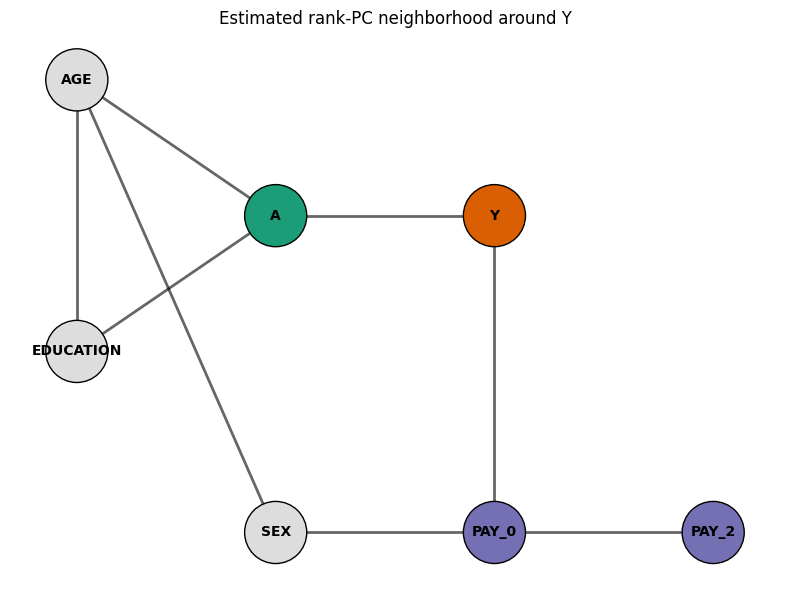

In [8]:

pc_adj, pc_sepsets = pc_stable_rank(rpc_corr, n=len(df), alpha=0.05, max_cond_set=3)

pc_y_neighbors = sorted(pc_adj["Y"])
pc_adjustment_set = [var for var in pc_y_neighbors if var != "A"]

print(f"PC-based adjustment set: {pc_adjustment_set}")

# Build a two-hop neighborhood around Y for visualization.
neighborhood_nodes = {"Y"} | set(pc_adj["Y"])
for node in list(pc_adj["Y"]):
    neighborhood_nodes |= set(pc_adj[node])

sub_nodes = sorted(list(neighborhood_nodes), key=lambda x: list(df.columns).index(x))
G_pc = nx.Graph()

for u in sub_nodes:
    G_pc.add_node(u)
    for v in pc_adj[u]:
        if v in sub_nodes:
            G_pc.add_edge(u, v)

# Spring layout with a few preferred positions if the expected nodes are present.
pos_pc = nx.spring_layout(G_pc, seed=42, k=1.2)
preferred_pos = {
    "AGE": (-1.2, 0.8),
    "EDUCATION": (-1.2, -0.1),
    "A": (-0.2, 0.35),
    "Y": (0.9, 0.35),
    "PAY_0": (0.9, -0.7),
    "SEX": (-0.2, -0.7),
    "PAY_2": (2.0, -0.7),
}
for node, coord in preferred_pos.items():
    if node in G_pc.nodes:
        pos_pc[node] = np.array(coord, dtype=float)

fig, ax = plt.subplots(figsize=(8, 6))

node_colors = []
for node in G_pc.nodes():
    if node == "Y":
        node_colors.append("#d95f02")
    elif node == "A":
        node_colors.append("#1b9e77")
    elif "PAY" in node:
        node_colors.append("#7570b3")
    else:
        node_colors.append("#dddddd")

nx.draw_networkx_edges(G_pc, pos_pc, ax=ax, width=2, alpha=0.6)
nx.draw_networkx_nodes(
    G_pc, pos_pc, ax=ax, node_color=node_colors,
    edgecolors="black", node_size=2000
)
nx.draw_networkx_labels(G_pc, pos_pc, ax=ax, font_size=10, font_weight="bold")

ax.set_title("Estimated rank-PC neighborhood around Y")
ax.axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / "rank_pc_neighborhood.png", dpi=300, bbox_inches="tight")
plt.show()


IAMB adjustment set: ['PAY_0', 'PAY_2', 'BILL_AMT1']

Forward phase


,phase,step,candidate,partial_correlation,p_value,accepted
0,forward,1,PAY_0,0.3548,0.0000,True
1,forward,2,A,0.1365,0.0022,True
2,forward,3,BILL_AMT1,-0.0954,0.0333,True
3,forward,4,PAY_2,0.1660,0.0002,True
4,forward,5,EDUCATION,-0.0704,0.1176,False



Backward phase


,phase,candidate,conditioning_on,partial_correlation,p_value,kept
0,backward,A,"PAY_0, PAY_2, BILL_AMT1",0.1559,0.0005,True
1,backward,PAY_0,"A, PAY_2, BILL_AMT1",0.2063,0.0000,True
2,backward,PAY_2,"A, PAY_0, BILL_AMT1",0.1660,0.0002,True
3,backward,BILL_AMT1,"A, PAY_0, PAY_2",-0.1724,0.0001,True


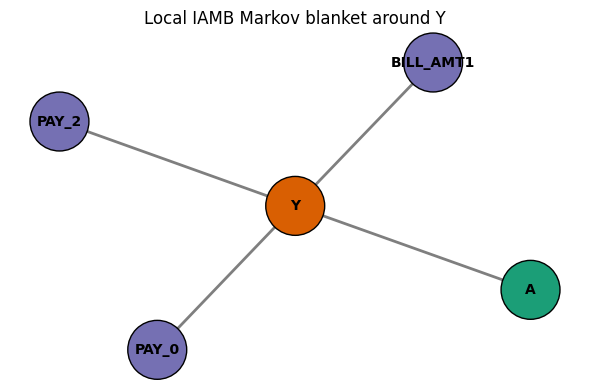

In [10]:

local_mb, iamb_forward, iamb_backward = iamb_rank_trace(rpc_corr, n=len(df), target="Y", alpha=0.05)
local_adjustment = [v for v in local_mb if v != "A"]

print(f"IAMB adjustment set: {local_adjustment}")

print("\nForward phase")
display(iamb_forward)

print("\nBackward phase")
display(iamb_backward)

# Dynamic blanket plot: edges are created from the actual IAMB output.
G_iamb = nx.Graph()
G_iamb.add_node("Y")
for var in local_mb:
    G_iamb.add_edge(var, "Y")

pos_iamb = nx.spring_layout(G_iamb, seed=42)

fig, ax = plt.subplots(figsize=(6, 4))

node_colors = []
for node in G_iamb.nodes():
    if node == "Y":
        node_colors.append("#d95f02")
    elif node == "A":
        node_colors.append("#1b9e77")
    else:
        node_colors.append("#7570b3")

nx.draw_networkx_edges(G_iamb, pos_iamb, ax=ax, width=2.0, alpha=0.5)
nx.draw_networkx_nodes(
    G_iamb, pos_iamb, ax=ax, node_color=node_colors,
    edgecolors="black", node_size=1800
)
nx.draw_networkx_labels(G_iamb, pos_iamb, ax=ax, font_size=10, font_weight="bold")

ax.set_title("Local IAMB Markov blanket around Y")
ax.axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / "local_iamb_blanket.png", dpi=300, bbox_inches="tight")
plt.show()


In [11]:

adjustment_sets = {
    "All covariates": covariates,
    "LASSO (outcome only)": lasso_selected_vars,
    "Rank-PC neighborhood": pc_adjustment_set,
    "Local IAMB blanket": local_adjustment,
}

adjustment_table = pd.DataFrame({
    "Adjustment strategy": list(adjustment_sets.keys()),
    "Selected variables": [", ".join(v) if len(v) > 0 else "(none)" for v in adjustment_sets.values()],
    "Set size": [len(v) for v in adjustment_sets.values()],
})

display(adjustment_table)

results_rows = [{
    "Adjustment set": "Observed correlation",
    "Method": "Unadjusted (crude)",
    "Set size": 0,
    "ACE": crude_rd,
    "CI low": np.nan,
    "CI high": np.nan,
    "Bootstrap draws kept": np.nan,
}]


for i, (name, covs) in enumerate(adjustment_sets.items(), start=1):
    or_res = bootstrap_ace(df, covs, estimator="or", n_boot=300, seed=100 + 2*i)
    ipw_res = bootstrap_ace(df, covs, estimator="ipw", n_boot=300, seed=100 + 2*i + 1)

    results_rows.append({
        "Adjustment set": name,
        "Method": "Outcome regression",
        "Set size": len(covs),
        "ACE": or_res["estimate"],
        "CI low": or_res["ci_low"],
        "CI high": or_res["ci_high"],
        "Bootstrap draws kept": or_res["n_boot"],
    })
    results_rows.append({
        "Adjustment set": name,
        "Method": "Stabilized IPW",
        "Set size": len(covs),
        "ACE": ipw_res["estimate"],
        "CI low": ipw_res["ci_low"],
        "CI high": ipw_res["ci_high"],
        "Bootstrap draws kept": ipw_res["n_boot"],
    })

results_df = pd.DataFrame(results_rows)
display(results_df)


,Adjustment strategy,Selected variables,Set size
0,All covariates,"LIMIT_BAL, SEX, EDUCATION, AGE, PAY_0, PAY_2, ...",22
1,LASSO (outcome only),"PAY_0, PAY_2, PAY_6",3
2,Rank-PC neighborhood,PAY_0,1
3,Local IAMB blanket,"PAY_0, PAY_2, BILL_AMT1",3


Computing ACE estimates and bootstrap intervals...


,Adjustment set,Method,Set size,ACE,CI low,CI high,Bootstrap draws kept
0,Observed correlation,Unadjusted (crude),0,0.1159,NaN,NaN,NaN
1,All covariates,Outcome regression,22,0.1189,0.0299,0.2069,300.0000
2,All covariates,Stabilized IPW,22,0.1388,0.0461,0.2434,300.0000
3,LASSO (outcome only),Outcome regression,3,0.1162,0.0456,0.1920,300.0000
4,LASSO (outcome only),Stabilized IPW,3,0.1216,0.0388,0.1983,300.0000
5,Rank-PC neighborhood,Outcome regression,1,0.1145,0.0431,0.1870,300.0000
6,Rank-PC neighborhood,Stabilized IPW,1,0.1183,0.0376,0.1979,300.0000
7,Local IAMB blanket,Outcome regression,3,0.1216,0.0473,0.1918,300.0000
8,Local IAMB blanket,Stabilized IPW,3,0.1283,0.0648,0.1961,300.0000


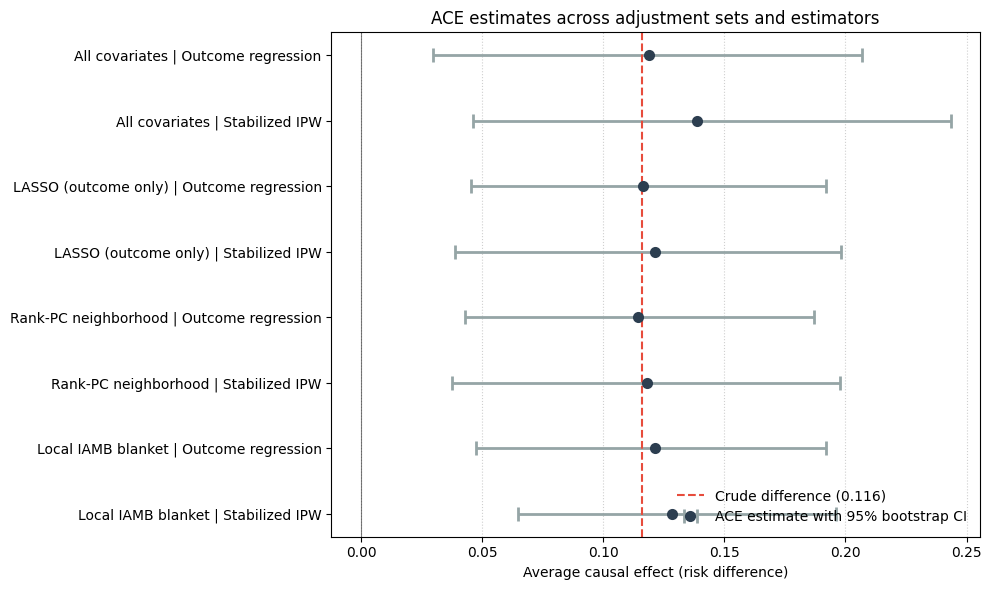

### Summary

- Crude risk difference: **0.116**
- Outcome-only LASSO selected **3** variables: `PAY_0, PAY_2, PAY_6`
- Rank-PC adjustment set: `PAY_0`
- Local IAMB adjustment set: `PAY_0, PAY_2, BILL_AMT1`

In [13]:

plot_df = results_df[results_df["Method"] != "Unadjusted (crude)"].copy()
plot_df["label"] = plot_df["Adjustment set"] + " | " + plot_df["Method"]
plot_df = plot_df.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(plot_df))

ax.errorbar(
    plot_df["ACE"], y_pos,
    xerr=[plot_df["ACE"] - plot_df["CI low"], plot_df["CI high"] - plot_df["ACE"]],
    fmt="o", color="#2c3e50", ecolor="#95a5a6", capsize=5, elinewidth=2, markeredgewidth=2,
    label="ACE estimate with 95% bootstrap CI"
)

ax.axvline(crude_rd, color="#e74c3c", linestyle="--", linewidth=1.5,
           label=f"Crude difference ({crude_rd:.3f})")
ax.axvline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label"], fontsize=10)
ax.set_xlabel("Average causal effect (risk difference)")
ax.set_title("ACE estimates across adjustment sets and estimators")
ax.grid(axis="x", linestyle=":", alpha=0.6)
ax.legend(loc="lower right", frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "ace_summary.png", dpi=300, bbox_inches="tight")
plt.show()

summary_md = "\n".join([
    "### Summary",
    "",
    f"- Crude risk difference: **{crude_rd:.3f}**",
    f"- Outcome-only LASSO selected **{len(lasso_selected_vars)}** variables: `{', '.join(lasso_selected_vars) if lasso_selected_vars else '(none)'}`",
    f"- Rank-PC adjustment set: `{', '.join(pc_adjustment_set) if pc_adjustment_set else '(none)'}`",
    f"- Local IAMB adjustment set: `{', '.join(local_adjustment) if local_adjustment else '(none)'}`",
])
display(Markdown(summary_md))


Full-model IPW ACE: 0.1388
Propensity score range: [0.006, 0.942]
Weight range:           [0.427, 11.651]


,variable,Before,After,abs_before,abs_after
3,AGE,0.8674,-0.0795,0.8674,0.0795
2,EDUCATION,0.4106,0.0001,0.4106,0.0001
0,LIMIT_BAL,0.3052,-0.0092,0.3052,0.0092
10,BILL_AMT1,0.1478,0.0113,0.1478,0.0113
20,PAY_AMT5,0.1423,0.0218,0.1423,0.0218
21,PAY_AMT6,-0.1233,0.2233,0.1233,0.2233
19,PAY_AMT4,0.1211,-0.0345,0.1211,0.0345
13,BILL_AMT4,0.1166,-0.0094,0.1166,0.0094
14,BILL_AMT5,0.1153,-0.0229,0.1153,0.0229
15,BILL_AMT6,0.1108,0.0170,0.1108,0.0170


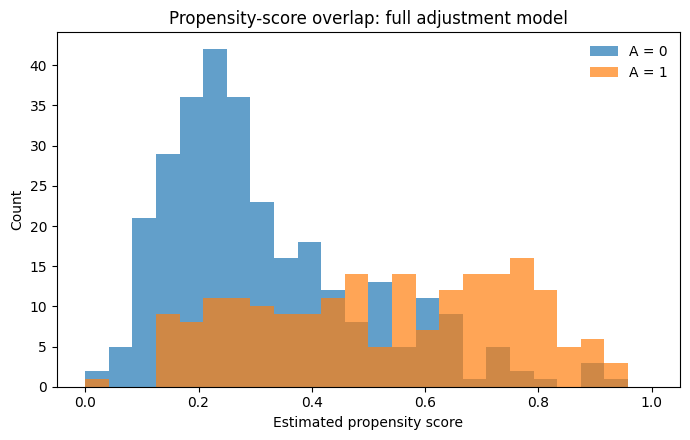

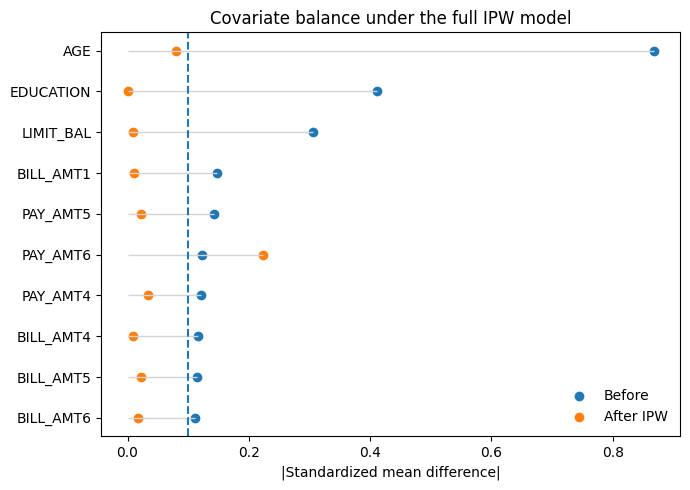

In [14]:

full_ipw_point, full_ps_model, full_ps, full_weights = ace_ipw(df, covariates)

balance_before = standardized_mean_differences(df, cols=covariates).rename(columns={"smd": "Before"})
balance_after = standardized_mean_differences(df, cols=covariates, weights=full_weights).rename(columns={"smd": "After"})
balance_df = balance_before.merge(balance_after, on="variable")
balance_df["abs_before"] = balance_df["Before"].abs()
balance_df["abs_after"] = balance_df["After"].abs()

print(f"Full-model IPW ACE: {full_ipw_point:.4f}")
print(f"Propensity score range: [{full_ps.min():.3f}, {full_ps.max():.3f}]")
print(f"Weight range:           [{full_weights.min():.3f}, {full_weights.max():.3f}]")

display(balance_df.sort_values("abs_before", ascending=False).head(10))

# Propensity-score overlap
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(0, 1, 25)
ax.hist(full_ps[df["A"] == 0], bins=bins, alpha=0.7, label="A = 0")
ax.hist(full_ps[df["A"] == 1], bins=bins, alpha=0.7, label="A = 1")
ax.set_xlabel("Estimated propensity score")
ax.set_ylabel("Count")
ax.set_title("Propensity-score overlap: full adjustment model")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "propensity_scores_full.png", dpi=300, bbox_inches="tight")
plt.show()

# Love plot for the 10 most imbalanced variables before weighting
top_bal = balance_df.sort_values("abs_before", ascending=False).head(10).sort_values("abs_before")

fig, ax = plt.subplots(figsize=(7, 5))
ypos = np.arange(len(top_bal))
ax.hlines(
    y=ypos,
    xmin=0,
    xmax=np.maximum(top_bal["Before"].abs(), top_bal["After"].abs()),
    color="lightgray",
    linewidth=1
)
ax.scatter(top_bal["Before"].abs(), ypos, label="Before")
ax.scatter(top_bal["After"].abs(), ypos, label="After IPW")
ax.axvline(0.1, linestyle="--")
ax.set_yticks(ypos)
ax.set_yticklabels(top_bal["variable"])
ax.set_xlabel("|Standardized mean difference|")
ax.set_title("Covariate balance under the full IPW model")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "love_plot_full_ipw.png", dpi=300, bbox_inches="tight")
plt.show()
